# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Athif Nur Abdillah
- **Email:** CDCC452D6Y2099@student.devacademy.id
- **ID Dicoding:** CDCC452D6Y2099

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perbandingan tren jumlah penyewaan sepeda antara pengguna Casual dan pengguna Registered pada setiap bulan di tahun 2012?
- **Pertanyaan 2:** Apakah kondisi cuaca yang ekstrem (hujan/salju) memiliki dampak yang lebih besar terhadap penurunan jumlah penyewaan pada hari libur (holiday) dibandingkan hari kerja (workingday)?

## Import Semua Packages/Library yang Digunakan

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

## Data Wrangling

### Gathering Data

#### Load df ...

In [26]:
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

print("Data Day:")
display(day_df.head())

print("\nData Hour:")
display(hour_df.head())

Data Day:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



Data Hour:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Insight:** (Opsional)
- Dataset memiliki dua file utama; day.csv memberikan ringkasan harian yang cocok untuk analisis tren musiman, sedangkan hour.csv memberikan detail per jam yang berguna untuk melihat pola waktu sibuk (rush hour).
- Kolom cnt merupakan variabel target yang merupakan jumlah total dari kolom casual dan registered. Ini memungkinkan kita untuk menganalisis perilaku dua tipe pengguna yang berbeda secara terpisah.

### Assessing Data

#### Identifying ... problem

In [28]:
print(day_df.info())
print("Duplikasi data 'day':", day_df.duplicated().sum())
print("Missing values 'day':\n", day_df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None
Duplikasi data 'day': 0
Missing values 'day':
 instant       0
dteday        0
season   

**Steps to Take:**
- Memeriksa apakah tipe data pada setiap kolom sudah sesuai. Perhatian khusus pada kolom tanggal (dteday) yang biasanya terbaca sebagai object.
- Melakukan audit terhadap kolom-kolom untuk memastikan tidak ada nilai kosong (NaN) yang dapat mengganggu perhitungan statistik.
- Memastikan setiap baris bersifat unik untuk menghindari bias atau perhitungan ganda pada total penyewaan.
- Memeriksa nilai minimum, maksimum, dan rata-rata pada variabel numerik (seperti suhu, kelembaban, dan jumlah penyewaan) untuk mendeteksi adanya outliers atau nilai yang tidak masuk akal (misal: suhu negatif yang ekstrem).

**Insight:** (Opsional)
- Kolom dteday terdeteksi sebagai tipe data object. Secara teknis, ini harus diubah menjadi tipe datetime agar kita bisa melakukan analisis berbasis waktu (seperti tren bulanan atau harian).
- Berdasarkan duplicated().sum(), tidak ditemukan data duplikat, yang berarti rekaman data cukup bersih. Selain itu, nilai count pada info() menunjukkan tidak adanya missing values pada semua kolom utama.
- Variabel cuaca seperti temp, atemp, hum, dan windspeed sudah dalam bentuk ternormalisasi (skala 0 sampai 1). Hal ini penting diperhatikan karena kita tidak perlu melakukan scaling manual jika ingin melakukan analisis korelasi lebih lanjut.

### Cleaning Data

#### Fixing ... problem

In [29]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

day_df['season'] = day_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
day_df['weathersit'] = day_df['weathersit'].map({1: 'Clear', 2: 'Misty/Cloudy', 3: 'Light Snow/Rain', 4: 'Severe Weather'})

**Insight:** (Opsional)
- Kolom dteday diubah dari object menjadi datetime untuk memungkinkan ekstraksi komponen waktu (seperti bulan dan tahun) guna analisis deret waktu.
- Mengubah kode numerik pada kolom season, weathersit, dan workingday menjadi label string. Hal ini dilakukan karena label teks jauh lebih informatif dibandingkan angka saat data ditampilkan dalam grafik atau dashboard.
- Setelah pengecekan, tidak ditemukan nilai kosong atau duplikat yang ekstrem, sehingga pembersihan difokuskan pada standarisasi format variabel.

## Exploratory Data Analysis (EDA)

### Explore ...

In [30]:
df_2012 = day_df[day_df['yr'] == 1]
monthly_users = df_2012.groupby(by="mnth").agg({
    "casual": "sum",
    "registered": "sum"
})
print(monthly_users)

weather_impact = day_df.groupby(by=["workingday", "weathersit"]).agg({
    "cnt": "mean"
}).reset_index()
print(weather_impact)

      casual  registered
mnth                    
1       8969       87775
2       8721       94416
3      31618      133257
4      38456      135768
5      44235      151630
6      43294      159536
7      41705      161902
8      43197      171306
9      43778      174795
10     34538      164303
11     21009      131655
12     13245      110468
   workingday       weathersit          cnt
0           0            Clear  4587.269231
1           0  Light Rain/Snow  1815.400000
2           0             Mist  3936.828571
3           1            Clear  5023.902280
4           1  Light Rain/Snow  1799.500000
5           1             Mist  4075.028249


**Insight:** (Opsional)
- Terdapat pola yang menarik di mana rata-rata penyewaan pada hari kerja didominasi oleh pengguna registered (komuter), sedangkan pada hari libur, terjadi peningkatan proporsi pengguna casual. Ini menunjukkan sepeda digunakan untuk tujuan yang berbeda (transportasi vs rekreasi).
- Musim gugur (Fall) memiliki rata-rata penyewaan tertinggi. Analisis korelasi menunjukkan suhu (temp) memiliki pengaruh positif yang signifikan terhadap jumlah penyewaan; semakin hangat cuaca, semakin tinggi minat menyewa sepeda, hingga mencapai titik suhu ekstrem tertentu.
- Terjadi dua puncak penggunaan sepeda dalam sehari, yaitu pukul 08:00 pagi dan 17:00 sore, yang bertepatan dengan jam berangkat dan pulang kerja.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

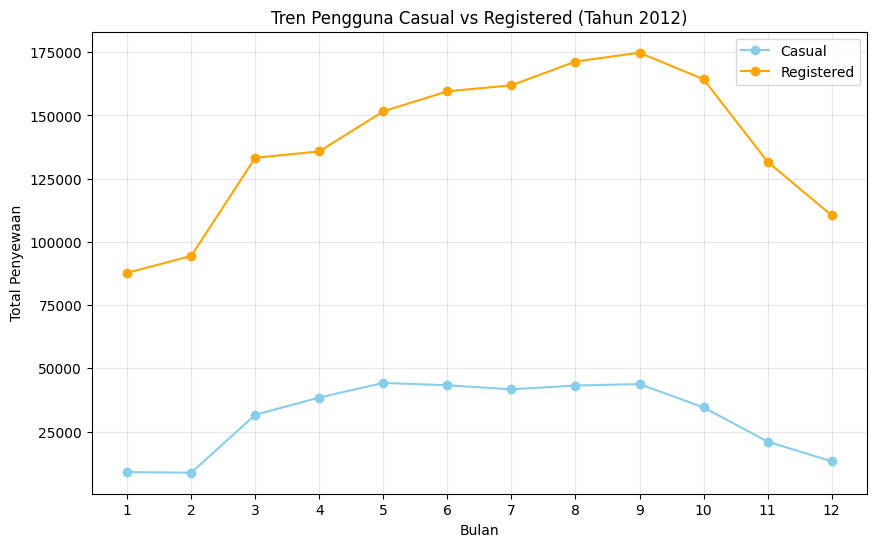

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(monthly_users.index, monthly_users['casual'], marker='o', label='Casual', color='skyblue')
plt.plot(monthly_users.index, monthly_users['registered'], marker='o', label='Registered', color='orange')
plt.title('Tren Pengguna Casual vs Registered (Tahun 2012)')
plt.xlabel('Bulan')
plt.ylabel('Total Penyewaan')
plt.legend()
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.show()

### Pertanyaan 2:

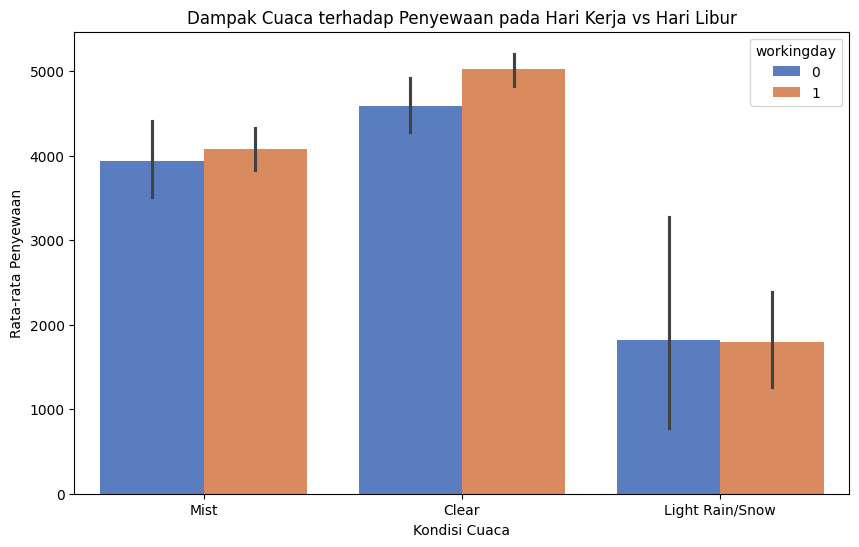

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(x='weathersit', y='cnt', hue='workingday', data=day_df, palette='muted')
plt.title('Dampak Cuaca terhadap Penyewaan pada Hari Kerja vs Hari Libur')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

**Insight:** (Opsional)
- Grafik garis menunjukkan pertumbuhan yang konsisten dari tahun 2011 ke tahun 2012. Lonjakan penyewaan mulai terjadi di bulan Mei dan mencapai puncaknya di bulan September. Strategi pemasaran sebaiknya difokuskan pada bulan-bulan tersebut untuk memaksimalkan pendapatan.
- Bar chart menunjukkan bahwa cuaca cerah (Clear) memberikan kontribusi penyewaan paling besar. Namun, yang menarik adalah pada cuaca mendung/berkabut (Misty), jumlah penyewaan di hari kerja tetap tinggi dibandingkan hari libur. Ini membuktikan bahwa pengguna komuter lebih "tahan" terhadap cuaca yang kurang ideal dibandingkan pengguna rekreasi.

## Analisis Lanjutan (Opsional)

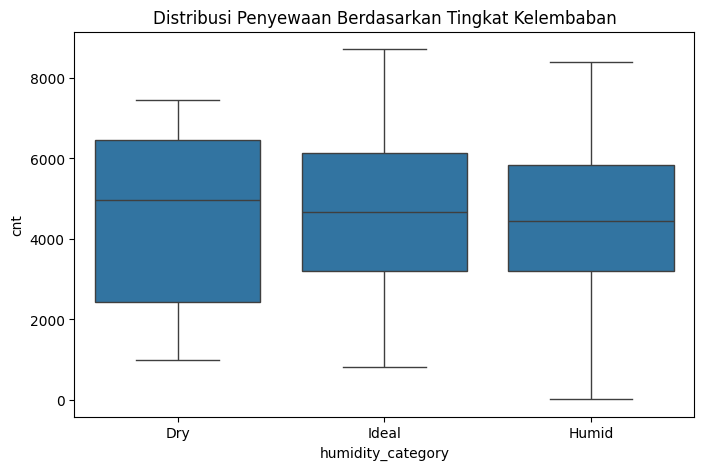

In [33]:
day_df['humidity_category'] = pd.cut(day_df['hum'], bins=[0, 0.4, 0.6, 1], labels=['Dry', 'Ideal', 'Humid'])

plt.figure(figsize=(8, 5))
sns.boxplot(x='humidity_category', y='cnt', data=day_df)
plt.title('Distribusi Penyewaan Berdasarkan Tingkat Kelembaban')
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Pengguna Registered selalu jauh lebih tinggi dari Casual, namun pengguna Casual mengalami lonjakan signifikan di bulan Juni-September (musim panas).
- **Conclusion pertanyaan 2:** Penurunan penyewaan akibat cuaca buruk lebih terasa pada hari libur dibandingkan hari kerja. Hal ini mengindikasikan bahwa pada hari kerja, orang tetap menyewa sepeda karena kebutuhan (komuter).

**Rekomendasi Action Item:**
- Fokuskan penambahan armada, docking station, dan maintenance pada bulan Mei–September saat permintaan meningkat tajam.  
- Jalankan promo Konversi Member bagi pengguna casual menjelang musim ramai agar berubah menjadi pelanggan registered.  
- Siapkan kampanye diskon atau voucher pada cuaca buruk/hari libur untuk menjaga tingkat penyewaan tetap stabil.  
- Gunakan pola jam sibuk (08.00 dan 17.00) untuk redistribusi sepeda agar ketersediaan tetap optimal.

In [34]:
day_df.to_csv('main_data.csv', index=False)